=== RESULTS ===
Square cost: 251.856
Hex cost:    217.936
Square visited %: 74.93
Hex visited %:    64.83
Square time: 0.00779
Hex time:    0.00812


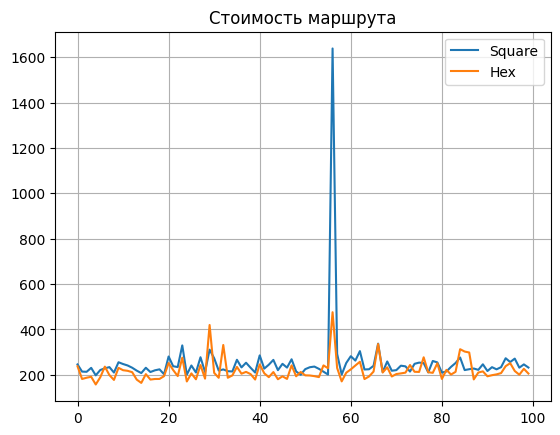

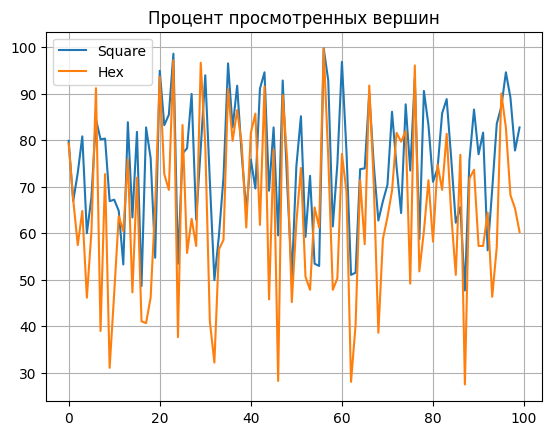

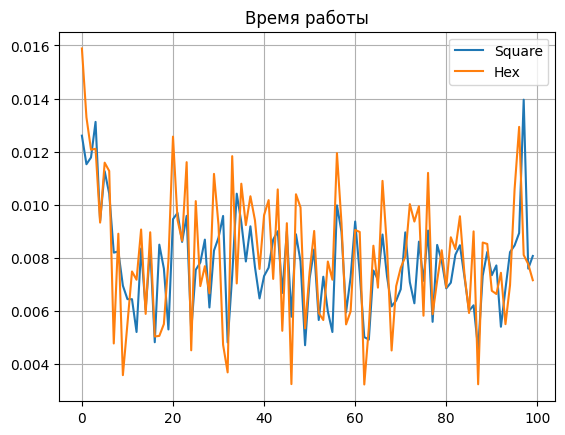

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
import math
import random
import time

L = 100.0
h = 4.0
RUNS = 100

NUM_CENTERS = 20
BETA = 0.25

def generate_centers():
    centers = []
    for _ in range(NUM_CENTERS):
        x = random.uniform(0, L)
        y = random.uniform(0, L)
        amp = random.uniform(2.0, 6.0)
        centers.append((x, y, amp))
    return centers

def field_value(x, y, centers):
    val = 0.0
    for cx, cy, A in centers:
        d = math.hypot(x - cx, y - cy)
        val += A * math.exp(-BETA * d)
    return val

def cost(v):
    return math.exp(v)


def build_square_grid():
    n = int(L / h)
    coords = {}
    for i in range(n):
        for j in range(n):
            coords[(i, j)] = (i * h, j * h)
    return coords, n

def square_neighbors(node, n):
    i, j = node
    dirs = [(-1,0),(1,0),(0,-1),(0,1)]

    nbrs = []
    for di, dj in dirs:
        ni, nj = i+di, j+dj
        if 0 <= ni < n and 0 <= nj < n:
            nbrs.append((ni, nj))
    return nbrs

def build_hex_grid():
    coords = {}

    qmax = int(L / h)
    rmax = int(L / (math.sqrt(3)/2*h))

    for q in range(qmax):
        for r in range(rmax):
            x = h * (q + r/2)
            y = h * math.sqrt(3)/2 * r

            if x <= L and y <= L:
                coords[(q,r)] = (x,y)

    return coords

def hex_neighbors(node, coords):
    q,r = node

    dirs = [
        (1,0),(-1,0),
        (0,1),(0,-1),
        (1,-1),(-1,1)
    ]

    nbrs = []
    for dq, dr in dirs:
        nb = (q+dq, r+dr)
        if nb in coords:
            nbrs.append(nb)

    return nbrs

def astar(coords, neighbors_func, start, goal, centers, heuristic):
    pq = [(0, start)]
    g = {start: 0}

    visited_set = set()

    while pq:
        _, cur = heapq.heappop(pq)

        if cur in visited_set:
            continue

        visited_set.add(cur)

        if cur == goal:
            break

        for nb in neighbors_func(cur):
            x, y = coords[nb]

            step = math.hypot(
                coords[cur][0] - x,
                coords[cur][1] - y
            )

            ng = g[cur] + step * cost(field_value(x, y, centers))

            if nb not in g or ng < g[nb]:
                g[nb] = ng
                f = ng + heuristic(coords[nb], coords[goal])
                heapq.heappush(pq, (f, nb))

    return g[goal], len(visited_set)

def euclid(a, b):
    return math.hypot(a[0]-b[0], a[1]-b[1])

sq_costs, hx_costs = [], []
sq_vis, hx_vis = [], []
sq_times, hx_times = [], []

for _ in range(RUNS):
    centers = generate_centers()


    sq_coords, n = build_square_grid()
    sq_start = (0,0)
    sq_goal = (n-1,n-1)

    t0 = time.time()
    sc, sv = astar(
        sq_coords,
        lambda node: square_neighbors(node, n),
        sq_start,
        sq_goal,
        centers,
        euclid
    )
    t1 = time.time()


    hx_coords = build_hex_grid()
    hx_nodes = list(hx_coords.keys())

    hx_start = min(hx_nodes, key=lambda k: euclid(hx_coords[k], (0,0)))
    hx_goal = min(hx_nodes, key=lambda k: euclid(hx_coords[k], (L,L)))

    t2 = time.time()
    hc, hv = astar(
        hx_coords,
        lambda node: hex_neighbors(node, hx_coords),
        hx_start,
        hx_goal,
        centers,
        euclid
    )
    t3 = time.time()

    sq_costs.append(sc)
    hx_costs.append(hc)

    sq_vis.append(100 * sv / len(sq_coords))
    hx_vis.append(100 * hv / len(hx_coords))

    sq_times.append(t1 - t0)
    hx_times.append(t3 - t2)


print("=== RESULTS ===")
print(f"Square cost: {np.mean(sq_costs):.3f}")
print(f"Hex cost:    {np.mean(hx_costs):.3f}")

print(f"Square visited %: {np.mean(sq_vis):.2f}")
print(f"Hex visited %:    {np.mean(hx_vis):.2f}")

print(f"Square time: {np.mean(sq_times):.5f}")
print(f"Hex time:    {np.mean(hx_times):.5f}")


plt.figure()
plt.plot(sq_costs,label='Square')
plt.plot(hx_costs,label='Hex')
plt.legend()
plt.grid()
plt.title('Стоимость маршрута')
plt.savefig('cost.png')

plt.figure()
plt.plot(sq_vis,label='Square')
plt.plot(hx_vis,label='Hex')
plt.legend()
plt.grid()
plt.title('Процент просмотренных вершин')
plt.savefig('visited.png')

plt.figure()
plt.plot(sq_times,label='Square')
plt.plot(hx_times,label='Hex')
plt.legend()
plt.grid()
plt.title('Время работы')
plt.savefig('time.png')

plt.show()